In [57]:
import torch
from torch import nn
import matplotlib.pyplot as plt

Set up model class; we have the lower and upper bound bounds for time and space.
We can set the the number of hidden layers and widt. The weights are also initialized witg xavier_uniform to best fit the tanh activation function. In forward the inputs are normalized [-1,1] also to get a good activation from the tanh.

In [58]:
class PINN(nn.Module):
    def __init__(self, lower, upper, output_dims, hidden_layers, hidden_width):
        super(PINN, self).__init__()
        self.lower = lower
        self.upper = upper
        self.output_dims = output_dims
        self.hidden_layers = hidden_layers
        self.hidden_width = hidden_width

        # Define the neural network architecture
        layers = []
        input_dim = 3 # 2D space and time
        for _ in range(hidden_layers):
            layers.append(nn.Linear(input_dim, hidden_width))  # Hidden layer
            layers.append(nn.Tanh())  # Activation function
            input_dim = hidden_width
        layers.append(nn.Linear(hidden_width, output_dims))  # Output layer

        self.network = nn.Sequential(*layers)

        for layer in self.network:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)  # Xavier initialization
                nn.init.zeros_(layer.bias)  # Initialize biases to zero

    def forward(self, x):
        # Normalize input to the range [-1, 1]
        x_normalized = 2.0 * (x - self.lower) / (self.upper - self.lower) - 1.0
        return self.network(x_normalized)

We also need to collect some points in our domain. 

In [59]:
def sample_points(lower, upper, inner_points, ic_points, bc_points):
    '''
    samples points in the domain for training the PINN model, also gives out points for initial and boundary conditions
    '''
    x = torch.rand(inner_points, 1) * (upper[0] - lower[0]) + lower[0]
    y = torch.rand(inner_points, 1) * (upper[1] - lower[1]) + lower[1]
    t = torch.rand(inner_points, 1) * (upper[2] - lower[2]) + lower[2]
    x_pde = torch.cat([x, y, t], dim=1).requires_grad_(True)

    # initial condition: a grid over the whole (x, y) plane, at t = lower[2]
    grid_x, grid_y = torch.meshgrid(
        torch.linspace(lower[0], upper[0], ic_points),
        torch.linspace(lower[1], upper[1], ic_points),
        indexing='ij',
    )
    x_ic = torch.stack([grid_x.reshape(-1), grid_y.reshape(-1)], dim=1)
    x_ic = torch.cat([x_ic, torch.full((x_ic.shape[0], 1), lower[2])], dim=1)

    # boundary condition: all four edges of the (x, y) box, each spanning all of t
    x_edge = torch.linspace(lower[0], upper[0], bc_points)
    y_edge = torch.linspace(lower[1], upper[1], bc_points)
    t_bc = torch.linspace(lower[2], upper[2], bc_points)

    grid_y_edge, grid_t_x = torch.meshgrid(y_edge, t_bc, indexing='ij')  # x = const edges: y and t vary
    y_flat, t_flat_x = grid_y_edge.reshape(-1), grid_t_x.reshape(-1)

    grid_x_edge, grid_t_y = torch.meshgrid(x_edge, t_bc, indexing='ij')  # y = const edges: x and t vary
    x_flat, t_flat_y = grid_x_edge.reshape(-1), grid_t_y.reshape(-1)

    x_bc = torch.cat([
        torch.stack([torch.full_like(y_flat, lower[0]), y_flat, t_flat_x], dim=1),  # x = lower[0]
        torch.stack([torch.full_like(y_flat, upper[0]), y_flat, t_flat_x], dim=1),  # x = upper[0]
        torch.stack([x_flat, torch.full_like(x_flat, lower[1]), t_flat_y], dim=1),  # y = lower[1]
        torch.stack([x_flat, torch.full_like(x_flat, upper[1]), t_flat_y], dim=1),  # y = upper[1]
    ], dim=0).requires_grad_(True)

    return x_pde, x_ic, x_bc

A quick look at the point sets, projected onto the spatial (x, y) domain (a unit square here) — time isn't shown, so the boundary points appear stacked along the four edges regardless of which t they carry, and the initial-condition points appear as a full grid since they cover the whole square at t = 0.

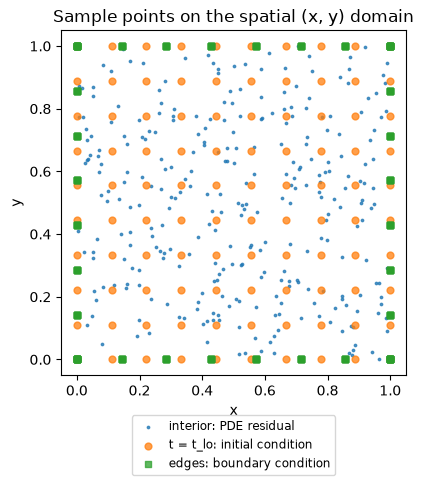

In [60]:

lower = (0.0, 0.0, 0.0)   # x_lo, y_lo, t_lo
upper = (1.0, 1.0, 5e-2)   # x_hi, y_hi, t_hi
demo_pde, demo_ic, demo_bc = sample_points(lower, upper, inner_points=300, ic_points=10, bc_points=8)

fig, ax = plt.subplots(figsize=(5, 5))
for pts, label, marker, size in zip(
    [demo_pde, demo_ic, demo_bc],
    ["interior: PDE residual", "t = t_lo: initial condition", "edges: boundary condition"],
    [".", "o", "s"],
    [12, 24, 18],
):
    p = pts.detach().cpu()
    ax.scatter(p[:, 0], p[:, 1], s=size, marker=marker, label=label, alpha=0.75)
ax.set(xlabel="x", ylabel="y", title="Sample points on the spatial (x, y) domain")
ax.set_aspect("equal")
ax.legend(fontsize="small", loc="upper center", bbox_to_anchor=(0.5, -0.1))
plt.tight_layout()
plt.show()

Lets set up the loss functions

We have the MSE for the residual of the pde: MSE_f. 
and the MSE from the IC and BC: MSE_u, that is made up of the loss from the IC and the BC. One can change the intital condition by changing CH_intital_condition(x)



In [61]:
import numpy as np

# --- spinodal-decomposition initial condition, ported from the FEM solver ---
# A sum of a few low-wavenumber cosine modes: smooth, mesh-independent, and the
# textbook way to seed CH spinodal decomposition. Modes (amplitude + phase) are
# drawn once from a seeded RNG so the IC is a fixed, reproducible function.
#
# The FEM solver works in the [0, 1] composition convention (c-bar = 0.63,
# perturbation 0.01). This model uses the symmetric [-1, 1] convention
# (double well at u = +-1), so map u = 2c - 1: mean 2*0.63 - 1 = 0.26 and
# amplitude 2*0.01 = 0.02.
_IC_SEED  = 0
_IC_KMAX  = 4
_IC_MEAN  = 0.26
_IC_AMP   = 0.02

def _make_spinodal_modes(seed, k_max):
    rng = np.random.default_rng(seed)
    return [
        (kx, ky, float(rng.uniform(-1.0, 1.0)), float(rng.uniform(0.0, 2 * np.pi)))
        for kx in range(1, k_max + 1)
        for ky in range(1, k_max + 1)
    ]

_IC_MODES = _make_spinodal_modes(_IC_SEED, _IC_KMAX)

def _spinodal_raw(xx, yy):
    val = torch.zeros_like(xx)
    for kx, ky, amp, phase in _IC_MODES:
        val = val + amp * torch.cos(2 * np.pi * kx * xx + 2 * np.pi * ky * yy + phase)
    return val

# Fix the normalisation on a dense reference grid (unit square) so the IC is a
# well-defined function, independent of which collocation points are passed in.
# The FEM demo instead normalises by the max over mesh vertices, so the peak
# perturbation here differs from that by an O(1) factor but has the same shape.
_g = torch.linspace(0.0, 1.0, 256)
_gx, _gy = torch.meshgrid(_g, _g, indexing="ij")
_IC_NORM = _spinodal_raw(_gx, _gy).abs().max()

def CH_initial_condition(x):
    '''
    Smooth low-wavenumber ("spinodal") perturbation, the [-1, 1]-convention
    image of the FEM solver's c-bar = 0.63 initial condition (u = 2c - 1).
    x: (N, 3) tensor of (x, y, t); returns (N, 1). Assumes the spatial domain
    is the unit square [0, 1]^2.
    '''
    xx, yy = x[:, 0:1], x[:, 1:2]
    return _IC_MEAN + _IC_AMP * _spinodal_raw(xx, yy) / _IC_NORM

def CH_loss(model, points, m = 1.0, epsilon = 0.01, w_ic=1.0, w_bc=1.0, w_pde=1.0):
    '''
    Builds the Cahn-Hilliard PINN loss. Returns a callable that, when called,
    evaluates the {pde, ic, bc} loss components on the sampled points.
    '''
    
    x_pde, x_ic, x_bc = points

    def loss_fn():
        out = model(x_pde)
        u, mu = out[:, 0:1], out[:, 1:2]  # Assuming the model outputs u and mu as separate channels
        u_x = torch.autograd.grad(u, x_pde, grad_outputs=torch.ones_like(u), create_graph=True)[0][ :, 0:1]
        u_xx = torch.autograd.grad(u_x, x_pde, grad_outputs=torch.ones_like(u_x), create_graph=True)[0][:, 0:1]
        u_y = torch.autograd.grad(u, x_pde, grad_outputs=torch.ones_like(u), create_graph=True)[0][:, 1:2]
        u_yy = torch.autograd.grad(u_y, x_pde, grad_outputs=torch.ones_like(u_y), create_graph=True)[0][:, 1:2]
        u_t = torch.autograd.grad(u, x_pde, grad_outputs=torch.ones_like(u), create_graph=True)[0][:, 2:3]

        f = 1/4 * (u**2 - 1)**2
        #derivate f with respect to u analyticly
        f_u = 1/2 * (u**2 - 1) * u
        #f_u = torch.autograd.grad(f, u, grad_outputs=torch.ones_like(f), create_graph=True)[0]
    
        mu_x = torch.autograd.grad(mu, x_pde, grad_outputs=torch.ones_like(mu), create_graph=True)[0][:, 0:1]
        mu_y = torch.autograd.grad(mu, x_pde, grad_outputs=torch.ones_like(mu), create_graph=True)[0][:, 1:2]
        mu_xx = torch.autograd.grad(mu_x, x_pde, grad_outputs=torch.ones_like(mu_x), create_graph=True)[0][:, 0:1]
        mu_yy = torch.autograd.grad(mu_y, x_pde, grad_outputs=torch.ones_like(mu_y), create_graph=True)[0][:, 1:2]
        residual_u = m * (mu_xx + mu_yy) - u_t
        residual_mu = mu - f_u + epsilon**2 * (u_xx + u_yy)

        #loss ic
        u_ic = model(x_ic)[:, 0:1] - CH_initial_condition(x_ic)  

        # --- boundary condition: no-flux,  grad(u).n = 0  and  grad(mu).n = 0 ---
        out_bc = model(x_bc)
        u_bc, mu_bc = out_bc[:, 0:1], out_bc[:, 1:2]

        grad_u_bc  = torch.autograd.grad(u_bc,  x_bc, torch.ones_like(u_bc),  create_graph=True)[0]
        grad_mu_bc = torch.autograd.grad(mu_bc, x_bc, torch.ones_like(mu_bc), create_graph=True)[0]

        # x_bc is 4 equal blocks (see sample_points): [x=lo, x=hi, y=lo, y=hi]
        n_edge = x_bc.shape[0] // 4
        # x = const edges -> outward normal along x -> constrain d/dx only
        # y = const edges -> outward normal along y -> constrain d/dy only
        dudn  = torch.cat([grad_u_bc[:2 * n_edge, 0:1],  grad_u_bc[2 * n_edge:, 1:2]])
        dmudn = torch.cat([grad_mu_bc[:2 * n_edge, 0:1], grad_mu_bc[2 * n_edge:, 1:2]])

        loss_bc = torch.mean(dudn**2 + dmudn**2)

        return {
            'pde': w_pde * torch.mean(residual_u**2 + residual_mu**2),
            'ic': w_ic * torch.mean(u_ic**2),
            'bc': w_bc * loss_bc,
        }

    return loss_fn

Seting up the training

In [62]:
def train_pinn(model, loss_fn, LR: float, num_epochs: int = 1000):
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    history = {'total': [], 'pde': [], 'ic': [], 'bc': []}
    for epoch in range(num_epochs):
        optimizer.zero_grad()
        parts = loss_fn()
        loss = sum(parts.values())
        loss.backward()
        optimizer.step()

        # record scalar loss components for later plotting
        history['total'].append(loss.item())
        for key, value in parts.items():
            history[key].append(value.item())

        if epoch % 100 == 0:
            print(f"Epoch {epoch:5d}: total={loss.item():.3e}  "
                  f"pde={parts['pde'].item():.3e}  "
                  f"ic={parts['ic'].item():.3e}  "
                  f"bc={parts['bc'].item():.3e}")
    return history

starting the model and training

In [ ]:
lower = (0.0, 0.0, 0.0)   # x_lo, y_lo, t_lo
upper = (1.0, 1.0, 5e-2)   # x_hi, y_hi, t_hi

PINN_model = PINN(lower=torch.tensor(lower), upper=torch.tensor(upper), output_dims=2, hidden_layers=5, hidden_width=100)

points = sample_points(lower, upper, inner_points=5000, ic_points=1000, bc_points=1000)

loss_for_CH = CH_loss(PINN_model, points, w_ic=100, w_bc=10, w_pde=3.0)

history = train_pinn(PINN_model, loss_for_CH, LR=0.001, num_epochs=500)

Epoch     0: total=1.385e+01  pde=2.796e+00  ic=7.118e+00  bc=3.934e+00
Epoch   100: total=7.239e-02  pde=7.869e-03  ic=1.703e-02  bc=4.749e-02
Epoch   200: total=3.215e-02  pde=4.021e-03  ic=8.412e-03  bc=1.972e-02
Epoch   300: total=1.871e-02  pde=2.266e-03  ic=6.119e-03  bc=1.033e-02
Epoch   400: total=1.331e-02  pde=1.426e-03  ic=5.497e-03  bc=6.392e-03


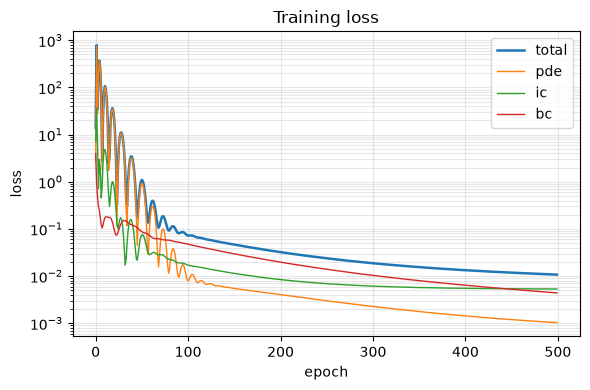

In [67]:
def plot_loss(history):
    """history: dict of {name: list_of_values} recorded per epoch by train_pinn."""
    fig, ax = plt.subplots(figsize=(6, 4))
    for name, values in history.items():
        ax.semilogy(values, label=name, lw=1.8 if name == "total" else 1.0)
    ax.set_xlabel("epoch")
    ax.set_ylabel("loss")
    ax.set_title("Training loss")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_loss(history)

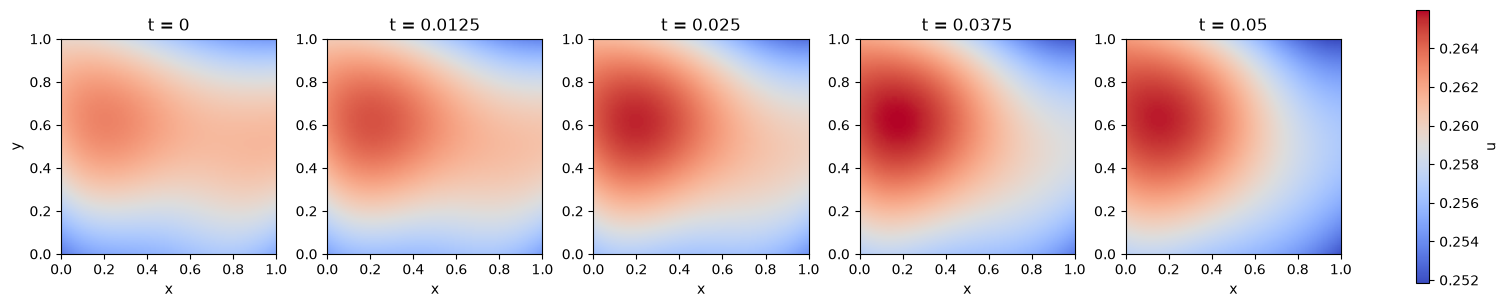

In [ ]:
@torch.no_grad()
def plot_ch_frames(model, lower, upper, n_frames=5, res=120, field=0, cmap="coolwarm"):
    """
    Plot the CH field in space at n_frames times from t=lower[2] (initial) to
    t=upper[2] (final), evenly spaced. field: 0 -> phase u, 1 -> chemical potential mu.
    """
    device = next(model.parameters()).device
    xs = torch.linspace(lower[0], upper[0], res)
    ys = torch.linspace(lower[1], upper[1], res)
    gx, gy = torch.meshgrid(xs, ys, indexing="ij")
    gx_f, gy_f = gx.reshape(-1, 1), gy.reshape(-1, 1)
    times = torch.linspace(lower[2], upper[2], n_frames)

    # evaluate all frames first so they share one colour scale
    frames = []
    for t in times:
        pts = torch.cat([gx_f, gy_f, torch.full_like(gx_f, float(t))], dim=1).to(device)
        frames.append(model(pts)[:, field:field + 1].cpu().reshape(res, res))
    vmin = min(f.min().item() for f in frames)
    vmax = max(f.max().item() for f in frames)

    fig, axes = plt.subplots(1, n_frames, figsize=(3 * n_frames, 3.3), constrained_layout=True)
    for ax, t, val in zip(axes, times, frames):
        im = ax.imshow(val.T.numpy(), origin="lower",
                       extent=[lower[0], upper[0], lower[1], upper[1]],
                       cmap=cmap, vmin=vmin, vmax=vmax, aspect="equal")
        ax.set_title(f"t = {float(t):.3g}")
        ax.set_xlabel("x")
    axes[0].set_ylabel("y")
    fig.colorbar(im, ax=axes, shrink=0.85, label="u" if field == 0 else "mu" )
    plt.show()

plot_ch_frames(PINN_model, lower, upper, n_frames=5)